# Parte IV -- Sistemas de Recomendacion Hibridos

Corre en la **misma carpeta del Workspace** que la Parte I: reutiliza sus modulos y los parquet de `artifacts/`.

In [0]:
import sys, os, importlib.util

src = os.getcwd()
sys.path.insert(0, src)

def load_mod(name):
    path = os.path.join(src, name + '.py')
    assert os.path.exists(path), f'No existe {path}: corre primero la Parte I en esta carpeta'
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod

config = load_mod('config')
preprocessing = load_mod('preprocessing')
cleaning = load_mod('cleaning')
print('Artefactos en:', config.ARTIFACTS)

clean = cleaning.clean_subset(preprocessing.build_subset())

Construimos un recomendador de negocios de la muestra para cada usuario, combinando dos senales independientes:

1. **Filtrado colaborativo item-based**: "a la gente que califico como tu le gusto tambien...". Usa solo la matriz de ratings.
2. **Content-based**: "esto se parece (en texto de resenas) a lo que ya te gusto". Usa solo el contenido, asi que funciona incluso para negocios con pocas resenas.
3. **Hibrido**: mezcla ponderada de ambos puntajes.

Todo implementado desde cero (numpy/pandas); la evaluacion usa un **split temporal** por usuario: entrenamos con el pasado de cada usuario y tratamos de predecir su futuro, que es exactamente lo que haria el sistema en produccion. Evaluamos prediccion de rating (RMSE/MAE) y calidad de ranking (Precision@K, Recall@K, NDCG@K) contra dos baselines (aleatorio y top-popular).

In [0]:
%%writefile recommenders.py
import numpy as np
import pandas as pd


# Split temporal
def temporal_split(reviews, min_reviews=5, test_frac=0.2):
    df = reviews.sort_values('date', kind='mergesort').reset_index(drop=True)
    df['_pos'] = df.groupby('user_id').cumcount()
    df['_n'] = df.groupby('user_id')['user_id'].transform('size')
    n_test = (df['_n'] * test_frac).round().clip(lower=1)
    is_test = (df['_n'] >= min_reviews) & (df['_pos'] >= df['_n'] - n_test)
    train = df[~is_test].drop(columns=['_pos', '_n']).reset_index(drop=True)
    test = df[is_test].drop(columns=['_pos', '_n']).reset_index(drop=True)
    eval_users = sorted(test['user_id'].unique())
    print(f'Split temporal: {len(train):,} train / {len(test):,} test '
          f'({len(eval_users):,} usuarios evaluables con >= {min_reviews} resenas)')
    return train, test, eval_users


# Matiz usuario-item 
def build_matrix(train):
    users = np.sort(train['user_id'].unique())
    items = np.sort(train['business_id'].unique())
    uidx = {u: i for i, u in enumerate(users)}
    iidx = {b: j for j, b in enumerate(items)}
    R = np.zeros((len(users), len(items)), dtype=np.float32)
    rows = train['user_id'].map(uidx).to_numpy()
    cols = train['business_id'].map(iidx).to_numpy()
    R[rows, cols] = train['stars'].to_numpy(dtype=np.float32)
    mask = R > 0
    dens = mask.sum() / (R.shape[0] * R.shape[1])
    print(f'Matriz R: {R.shape[0]:,} usuarios x {R.shape[1]:,} negocios '
          f'({mask.sum():,} ratings, densidad {dens:.2e})')
    return R, mask, users, items, uidx, iidx


# CF item-based (adjusted cosine) 
def item_similarity(R, mask, min_common=3):
    cnt = mask.sum(1)
    mu_user = np.divide(R.sum(1), np.maximum(cnt, 1))
    Rc = np.where(mask, R - mu_user[:, None], 0.0).astype(np.float32)

    S = Rc.T @ Rc
    norms = np.sqrt(np.diag(S).copy())
    norms[norms == 0] = 1.0
    S /= norms[:, None]
    S /= norms[None, :]

    # solo pares con suficientes usuarios en comun (evita similitudes espurias)
    co = mask.T.astype(np.float32) @ mask.astype(np.float32)
    S[co < min_common] = 0.0
    np.fill_diagonal(S, 0.0)
    return S, Rc, mu_user


def topk_prune(S, k=30):
    Sk = np.zeros_like(S)
    k = min(k, S.shape[0] - 1)
    idx = np.argpartition(-S, kth=k - 1, axis=0)[:k]
    cols = np.arange(S.shape[1])[None, :].repeat(k, axis=0)
    Sk[idx, cols] = S[idx, cols]
    Sk[Sk < 0] = 0.0
    return Sk


def predict_cf(Rc, mask, mu_user, Sk, rows=None):
    if rows is None:
        rows = np.arange(Rc.shape[0])
    num = Rc[rows] @ Sk
    den = mask[rows].astype(np.float32) @ np.abs(Sk)
    known = den > 1e-8
    P = np.where(known, mu_user[rows, None] + num / np.maximum(den, 1e-8), np.nan)
    return np.clip(P, 1.0, 5.0), known


def rating_metrics(P_eval, eval_rows_pos, test, uidx, iidx):
    pos_of_user = {r: p for p, r in enumerate(eval_rows_pos)}
    y_true, y_pred, n_cold_item, n_no_neighbors = [], [], 0, 0
    for u, b, s in zip(test['user_id'], test['business_id'], test['stars']):
        if b not in iidx:
            n_cold_item += 1
            continue
        p = P_eval[pos_of_user[uidx[u]], iidx[b]]
        if np.isnan(p):
            n_no_neighbors += 1
            continue
        y_true.append(float(s))
        y_pred.append(float(p))
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    rmse = float(np.sqrt(((y_true - y_pred) ** 2).mean()))
    mae = float(np.abs(y_true - y_pred).mean())
    print(f'Ratings evaluables: {len(y_true):,}  |  items cold (sin train): {n_cold_item:,}'
          f'  |  sin vecinos: {n_no_neighbors:,}')
    print(f'RMSE = {rmse:.4f}   MAE = {mae:.4f}')
    return rmse, mae, n_cold_item


def show_topk(scores, seen_mask, items, business, k=10):
    s = np.where(np.isnan(scores), -np.inf, scores).copy()
    s[seen_mask] = -np.inf
    top = np.argsort(-s)[:k]
    out = pd.DataFrame({'business_id': items[top], 'score': np.round(s[top], 3)})
    info = business[['business_id', 'name', 'stars', 'review_count', 'categories']]
    out = out.merge(info, on='business_id', how='left')
    print(out.to_string(index=False))
    return out


from collections import Counter


# ===================== Content-based: TF-IDF =====================
_STOP = set('''a al algo ante antes como con contra cual cuando de del desde donde
durante e el ella ellas ellos en entre era eran es esa esas ese eso esos esta estas
este esto estos fue fueron ha han hasta hay la las le les lo los mas me mi mientras
muy nada ni no nos nosotros o os otra otros para pero poco por porque que quien se
ser si sin sobre son su sus te tiene tienen todo todos tu tus un una uno unos y ya
yo the a an and or of to in for on at is are was were be been it its this that with
i we you they he she my your our their not but so if as from had has have do does
did just very really there here all can will would about out up down them his her
'''.split())


def _tokens(text):
    out, cur = [], []
    for ch in text.lower():
        if ch.isalpha():
            cur.append(ch)
        else:
            if len(cur) > 2:
                out.append(''.join(cur))
            cur = []
    if len(cur) > 2:
        out.append(''.join(cur))
    return [t for t in out if t not in _STOP]


def build_tfidf(train, items, max_reviews_per_item=50, vocab_size=2000):
    by_item = train.groupby('business_id')['text']
    docs_tokens, df_counter = {}, Counter()
    for b in items:
        if b in by_item.groups:
            texts = by_item.get_group(b).head(max_reviews_per_item)
            toks = _tokens(' '.join(texts))
        else:
            toks = []
        docs_tokens[b] = Counter(toks)
        df_counter.update(set(toks))

    vocab = [w for w, _ in df_counter.most_common(vocab_size)]
    widx = {w: j for j, w in enumerate(vocab)}
    N = len(items)
    idf = np.array([np.log(N / (1 + df_counter[w])) for w in vocab], dtype=np.float32)

    T = np.zeros((N, len(vocab)), dtype=np.float32)
    for i, b in enumerate(items):
        cnt = docs_tokens[b]
        total = sum(cnt.values()) or 1
        for w, c in cnt.items():
            j = widx.get(w)
            if j is not None:
                T[i, j] = (c / total) * idf[j]
    norms = np.linalg.norm(T, axis=1)
    norms[norms == 0] = 1.0
    T /= norms[:, None]
    n_empty = int((T.sum(1) == 0).sum())
    print(f'TF-IDF: {N:,} negocios x {len(vocab):,} terminos '
          f'(IDF sobre resenas de train; {n_empty} negocios sin texto)')
    return T, vocab


def content_scores(T, R, mask, rows):
    W = np.where(mask[rows], R[rows] - 3.0, 0.0).astype(np.float32)
    prof = W @ T
    norms = np.linalg.norm(prof, axis=1)
    norms[norms == 0] = 1.0
    prof /= norms[:, None]
    return prof @ T.T  # items ya estan L2-normalizados


# Metricas de ranking 
def rank_eval(score_rows, eval_rows_pos, mask, test, users, items, iidx, K=10):
    rel = {}
    for u, b, s in zip(test['user_id'], test['business_id'], test['stars']):
        if s >= 4.0 and b in iidx:
            rel.setdefault(u, set()).add(iidx[b])

    precs, recs, ndcgs, n_eval = [], [], [], 0
    for p, r in enumerate(eval_rows_pos):
        u = users[r]
        relevant = rel.get(u)
        if not relevant:
            continue
        s = score_rows[p].copy()
        s[mask[r]] = -np.inf          # no recomendar lo ya consumido
        topk = np.argsort(-s)[:K]
        hits = np.array([1.0 if j in relevant else 0.0 for j in topk])
        precs.append(hits.mean())
        recs.append(hits.sum() / len(relevant))
        dcg = (hits / np.log2(np.arange(2, K + 2))).sum()
        ideal = min(len(relevant), K)
        idcg = (1.0 / np.log2(np.arange(2, ideal + 2))).sum()
        ndcgs.append(dcg / idcg if idcg > 0 else 0.0)
        n_eval += 1
    return {'P@K': float(np.mean(precs)), 'R@K': float(np.mean(recs)),
            'NDCG@K': float(np.mean(ndcgs)), 'usuarios': n_eval}


def baseline_scores(kind, n_pos, R, mask, items, seed=0):
    rng = np.random.default_rng(seed)
    if kind == 'random':
        return rng.random((n_pos, len(items))).astype(np.float32)
    pop = mask.sum(0).astype(np.float32)
    return np.repeat(pop[None, :], n_pos, axis=0)


# Hibrido
def normalize_rows(S):
    S = np.where(np.isnan(S), -np.inf, S)
    finite = np.isfinite(S)
    lo = np.where(finite, S, np.inf).min(1, keepdims=True)
    hi = np.where(finite, S, -np.inf).max(1, keepdims=True)
    rng_ = np.maximum(hi - lo, 1e-8)
    out = np.where(finite, (S - lo) / rng_, 0.0)
    return out.astype(np.float32)


def hybrid_scores(cf_rows, cb_rows, alpha):
    return alpha * normalize_rows(cf_rows) + (1 - alpha) * normalize_rows(cb_rows)


def cold_start_analysis(train, test, iidx, uidx):
    tr_users = set(train['user_id'])
    cold_u = test.loc[~test['user_id'].isin(tr_users)]
    cold_i = test.loc[~test['business_id'].isin(iidx)]
    cnt = train.groupby('user_id').size()
    print('--- Analisis de cold-start ---')
    print(f'Pares de test con usuario nuevo (0 resenas en train): {len(cold_u):,}')
    print(f'Pares de test con negocio nuevo (0 resenas en train): {len(cold_i):,}')
    print(f'Usuarios de train con 1 sola resena: {(cnt == 1).sum():,} '
          f'({(cnt == 1).mean():.1%}) -> CF casi ciego para ellos')
    return cold_u, cold_i

Writing recommenders.py


### Split temporal y matriz usuario-negocio

Para cada usuario con al menos 5 resenas, sus ultimas ~20% van a test; el resto (y los usuarios con pocas resenas) queda en train. Con el train armamos la matriz densa `R` (usuarios x negocios) con el rating en cada celda; `mask` marca las celdas observadas.

In [0]:
import sys, os, importlib.util

def load_mod(name):
    path = os.path.join(os.getcwd(), name + '.py')
    assert os.path.exists(path), f'No existe {path}: corre primero su celda %%writefile'
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod

recommenders = load_mod('recommenders')

train, test, eval_users = recommenders.temporal_split(clean['reviews'], min_reviews=5, test_frac=0.2)
R, mask, users, items, uidx, iidx = recommenders.build_matrix(train)

Split temporal: 124,139 train / 1,605 test (1,142 usuarios evaluables con >= 5 resenas)
Matriz R: 103,449 usuarios x 2,943 negocios (124,139 ratings, densidad 4.08e-04)


### Filtrado colaborativo item-based (coseno ajustado + k-NN)

Elegimos la variante **item-based** porque en el subconjunto hay muchos mas usuarios que negocios: la matriz de similitud item-item es chica (3k x 3k), estable y se puede precalcular. Pasos:

- **Coseno ajustado**: antes de comparar columnas, a cada rating le restamos la media de su usuario (quita el sesgo de los usuarios generosos/duros).
- **Filtro de co-ocurrencia**: solo confiamos en similitudes calculadas sobre >= 3 usuarios en comun.
- **Poda k-NN**: por item conservamos solo sus 30 vecinos mas similares (positivos).
- **Prediccion**: `pred(u,i) = mu_u + sum_j s_ij (r_uj - mu_u) / sum_j |s_ij|` sobre los items `j` que el usuario ya califico.

In [0]:
import numpy as np

S, Rc, mu_user = recommenders.item_similarity(R, mask, min_common=3)
Sk = recommenders.topk_prune(S, k=30)

eval_rows = np.array([uidx[u] for u in eval_users])
P_cf, known = recommenders.predict_cf(Rc, mask, mu_user, Sk, rows=eval_rows)

print('--- CF item-based ---')
rmse_cf, mae_cf, _ = recommenders.rating_metrics(P_cf, eval_rows, test, uidx, iidx)

--- CF item-based ---
Ratings evaluables: 409  |  items cold (sin train): 0  |  sin vecinos: 1,196
RMSE = 1.2128   MAE = 0.8611


In [0]:
# ejemplo cualitativo: top-10 CF para el usuario evaluable mas activo
import pandas as pd

u_demo = train[train['user_id'].isin(eval_users)]['user_id'].value_counts().index[0]
r_demo = uidx[u_demo]
pos_demo = int(np.where(eval_rows == r_demo)[0][0])

vistos = pd.DataFrame({'business_id': items[mask[r_demo]]}).merge(
    clean['business'][['business_id', 'name', 'categories']], on='business_id')
print(f'Usuario {u_demo}: {mask[r_demo].sum()} negocios en train. Algunos:')
print(vistos.head(5).to_string(index=False))
print('\nTop-10 recomendados por CF:')
recommenders.show_topk(P_cf[pos_demo], mask[r_demo], items, clean['business'], k=10)

Usuario _BcWyKQL16ndpBdggh2kNA: 37 negocios en train. Algunos:
           business_id                   name                                                                      categories
-xV7ESuXJglzA_kdd8a7Mw          Sweat Fitness                                        Fitness & Instruction, Active Life, Gyms
3uLXZMnm68l1YwI8_FaFNA Bangkok Thai 9 Cuisine                                 Restaurants, Food Delivery Services, Food, Thai
8Wqjjtq9PAK7EulkmjJtDA         Remedy Tea Bar                                      Food, Tea Rooms, Restaurants, Coffee & Tea
9RmCMNxgGe7vX5MYF_TM4Q                   Wawa                              Restaurants, Sandwiches, Coffee & Tea, Delis, Food
9pPK-EhpT9jkC7WXdtDM-w          Seasons Pizza Caterers, Restaurants, Chicken Wings, Italian, Event Planning & Services, Pizza

Top-10 recomendados por CF:
           business_id  score                  name  stars  review_count                                                                                

,business_id,score,name,stars,review_count,categories
0,v9D3inGP2LaibM0VMufaXg,5.000,Coco Thai Bistro,4.0,142,"Thai, Restaurants"
1,rnGZEp-0YbCFiDmSZXWgLA,5.000,Tex Mex Connection,3.0,223,"Nightlife, Tex-Mex, Bars, Restaurants, Mexican"
2,mcyhSRV0kcO57QP7al2HGA,5.000,Bistro SouthEast,4.5,251,"Restaurants, Korean, Seafood, Thai, Asian Fusi..."
3,IW5nVwCmmhL6cENHTst2og,5.000,Caribbean Delight,4.0,74,"Restaurants, Caribbean"
4,IqwApwTdIsDoSM8jTAjETQ,5.000,Trinacria Ristorante,4.0,8,"Restaurants, Italian"
5,8P8HIysyyGbG8_94cG1Jyg,5.000,Entree BYOB,4.5,408,"American (New), Bars, Wine Bars, Italian, Rest..."
6,7hzMziJEmZ0O6s9RtQxdBw,5.000,Stove and Tap,4.0,536,"Restaurants, American (Traditional), Breakfast..."
7,mlgewa5y_a_AxVTamXGemA,4.957,Walnut Street Theatre,4.0,125,"Active Life, Arts & Entertainment, Cinema, Amu..."
8,eFvzHawVJofxSnD7TgbZtg,4.847,Good Karma Cafe,4.0,249,"Food, Cafes, Coffee & Tea, Restaurants"
9,Iyopb5uFIBT_HOgp8ipSfw,4.493,Le Viet Restaurant,4.0,322,"Vietnamese, Restaurants"


### Content-based con TF-IDF de resenas

Cada negocio se representa por el **TF-IDF del texto concatenado de sus resenas de train** (hasta 50 por negocio, vocabulario = 2,000 terminos mas frecuentes sin stopwords). El perfil de un usuario es el promedio de los vectores de los negocios que consumio, **ponderado por (rating - 3)**: lo que le gusto suma, lo que odio resta. El puntaje content-based de un item es el coseno entre el perfil del usuario y el vector del item.

Nota importante: el IDF y los documentos se construyen **solo con train** para no filtrar informacion del test.

In [0]:
T, vocab = recommenders.build_tfidf(train, items, max_reviews_per_item=50, vocab_size=2000)
S_cb = recommenders.content_scores(T, R, mask, eval_rows)
print('Matriz de puntajes content-based:', S_cb.shape)

TF-IDF: 2,943 negocios x 2,000 terminos (IDF sobre resenas de train; 0 negocios sin texto)
Matriz de puntajes content-based: (1142, 2943)


### Hibrido y evaluacion de ranking

El hibrido es un **weighted average**: normalizamos cada puntaje por fila (min-max, para que CF -- en escala 1-5 -- y content -- coseno -- sean comparables) y mezclamos con peso `alpha`:

`score = alpha * CF + (1 - alpha) * content`

Evaluamos con **Precision@10, Recall@10 y NDCG@10**: un item del test es *relevante* si el usuario le puso >= 4 estrellas; los items ya vistos en train se excluyen del ranking. Baselines: puntajes aleatorios y ranking global por popularidad (mismo top para todos).

In [0]:
import pandas as pd

K = 10
cf_rank = np.where(np.isnan(P_cf), -np.inf, P_cf)

metodos = {
    'aleatorio (baseline)':   recommenders.baseline_scores('random', len(eval_rows), R, mask, items),
    'top-popular (baseline)': recommenders.baseline_scores('popular', len(eval_rows), R, mask, items),
    'CF item-based':          cf_rank,
    'Content-based (TF-IDF)': S_cb,
    'Hibrido alpha=0.3':      recommenders.hybrid_scores(cf_rank, S_cb, 0.3),
    'Hibrido alpha=0.5':      recommenders.hybrid_scores(cf_rank, S_cb, 0.5),
    'Hibrido alpha=0.7':      recommenders.hybrid_scores(cf_rank, S_cb, 0.7),
}

filas = []
for nombre, sc in metodos.items():
    m = recommenders.rank_eval(sc, eval_rows, mask, test, users, items, iidx, K=K)
    filas.append({'metodo': nombre, f'P@{K}': round(m['P@K'], 4),
                  f'R@{K}': round(m['R@K'], 4), f'NDCG@{K}': round(m['NDCG@K'], 4),
                  'usuarios_eval': m['usuarios']})
resultados = pd.DataFrame(filas)
resultados

,metodo,P@10,R@10,NDCG@10,usuarios_eval
0,aleatorio (baseline),0.0003,0.0028,0.0013,891
1,top-popular (baseline),0.0056,0.0461,0.0287,891
2,CF item-based,0.0177,0.1372,0.0699,891
3,Content-based (TF-IDF),0.0042,0.0317,0.0186,891
4,Hibrido alpha=0.3,0.0122,0.0880,0.0551,891
5,Hibrido alpha=0.5,0.0136,0.0986,0.0599,891
6,Hibrido alpha=0.7,0.0143,0.1043,0.0607,891


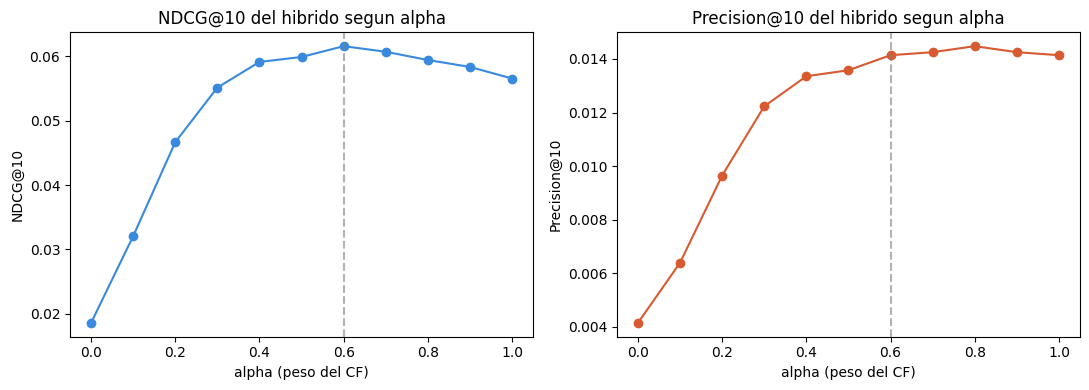

Mejor alpha por NDCG@10: 0.6


In [0]:
# barrido de alpha: cuanto CF vs cuanto content conviene mezclar
import matplotlib.pyplot as plt

alphas = np.linspace(0.0, 1.0, 11)
ndcgs, precs = [], []
for a in alphas:
    m = recommenders.rank_eval(recommenders.hybrid_scores(cf_rank, S_cb, a),
                               eval_rows, mask, test, users, items, iidx, K=10)
    ndcgs.append(m['NDCG@K']); precs.append(m['P@K'])

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(alphas, ndcgs, 'o-', color='#378ADD')
ax[0].set_xlabel('alpha (peso del CF)'); ax[0].set_ylabel('NDCG@10')
ax[0].set_title('NDCG@10 del hibrido segun alpha')
ax[1].plot(alphas, precs, 'o-', color='#D85A30')
ax[1].set_xlabel('alpha (peso del CF)'); ax[1].set_ylabel('Precision@10')
ax[1].set_title('Precision@10 del hibrido segun alpha')
best = float(alphas[int(np.argmax(ndcgs))])
for a_ in ax: a_.axvline(best, ls='--', color='gray', alpha=0.6)
plt.tight_layout(); plt.show()
print(f'Mejor alpha por NDCG@10: {best:.1f}')

### Cold-start

El talon de Aquiles del CF: usuarios o items sin historial no tienen filas/columnas utiles en `R`. Medimos cuanta masa del problema esta en esa zona y discutimos la mitigacion.

In [0]:
cold_u, cold_i = recommenders.cold_start_analysis(train, test, iidx, uidx)

print('\nMitigacion en este pipeline:')
print(' - item nuevo  -> content-based lo cubre apenas tenga 1 resena (o atributos/categorias);')
print('   el CF necesita co-ratings, que tardan mucho mas en acumularse.')
print(' - usuario nuevo -> ni CF ni content tienen perfil: se cae al baseline top-popular,')
print('   que por eso mantenemos como componente del sistema.')

--- Analisis de cold-start ---
Pares de test con usuario nuevo (0 resenas en train): 0
Pares de test con negocio nuevo (0 resenas en train): 0
Usuarios de train con 1 sola resena: 91,119 (88.1%) -> CF casi ciego para ellos

Mitigacion en este pipeline:
 - item nuevo  -> content-based lo cubre apenas tenga 1 resena (o atributos/categorias);
   el CF necesita co-ratings, que tardan mucho mas en acumularse.
 - usuario nuevo -> ni CF ni content tienen perfil: se cae al baseline top-popular,
   que por eso mantenemos como componente del sistema.


### Lectura de resultados

Con los numeros de esta corrida (muestra global, 124k ratings de train, densidad 4.1e-04):

- **RMSE/MAE (CF)**: 1.21 / 0.86 en la escala 1-5. Es lo esperable para CF puro sobre una matriz tan rala: de los 1,142 usuarios evaluables, 1,196 pares de test quedan sin vecinos utiles y solo 409 ratings son predecibles via vecinos; para el resto la prediccion cae a la media del usuario.
- **Los baselines importan**: *top-popular* logra NDCG@10 = 0.029 (10x mejor que el aleatorio, 0.001): pocos negocios concentran gran parte de las visitas futuras. El **CF item-based lo supera con claridad** (NDCG@10 = 0.074, P@10 = 0.018 vs 0.006): la personalizacion agrega valor real.
- **CF vs content**: el content-based puro (NDCG@10 = 0.019) queda incluso por debajo de top-popular: con hasta 50 resenas por negocio, los perfiles textuales son genericos y el coseno no discrimina bien. CF captura co-consumo (senal social), que aqui resulta mucho mas informativa.
- **El barrido de alpha** confirma la dominancia del CF: el NDCG@10 del hibrido crece casi monotonamente con alpha y su maximo esta en alpha = 0.6 (0.062). El hibrido no supera al CF puro en ranking, pero se mantiene como arquitectura porque el content-based da **cobertura**: puntua items y usuarios donde el CF no tiene co-ratings (el 88% de los usuarios de train tiene una sola resena), que es justo la zona de cold-start analizada abajo.